# ML 1 - Machine learning introdution

## 1.1. Intro

### I. 5 examples of the application of ML methods in life:

**Распознавание спама в почте**

- *Что делает:* выявляет, является ли полученное письмо спам-рассылкой 
- *Польза:* пользователь не тратит время на удаление писем со спамом

**Рекомендательная система в онлайн-кинотеатрах**
- *Что делает:* анализирует историю просмотренных фильмов и выставленных оценок и предлагает новые 
- *Польза:* пользователь не тратит время на поиск интересных ему фильмов

**Построение наиболее быстрого маршрута в навигаторе**
- *Что делает:* анализирует актуальные данные о загруженности дорог и строит оптимальный маршрут
- *Польза:* водитель выбирает оптимальный маршрут, тратит меньше времени

**Распознавание лиц в телефоне**
- *Что делает:* определяет совпадает ли лицо перед камерой с владельцем
- *Польза:* безопасность и конфденциальность устройства, позволяет войти без пароля

**Распознание болезни на рентгеновских снимках**
- *Что делает*: анализирует изображение и ищет признаки заболевания
- *Польза:* врач быстрее определяет диагноз, снижается риск ошибки

### II. Which class you can assign to the tasks from the table above and to the 5 examples you provided:

| Пример | Тип обучения | Подтип | Обоснование |
|--------|--------------|--------|-------------|
| Распознавание спама в почте | Supervised | Binary classification | Два класса: спам / не спам |
| Рекомендательная система в онлайн-кинотеатрах | Supervised | Classification или Regression | Можно предсказывать оценку (регрессия) или лайк/дизлайк (классификация) |
| Построение быстрого маршрута в навигаторе | Supervised | Regression | Предсказание времени в пути (число) |
| Распознавание лиц в телефоне | Supervised | Binary classification | Два класса: свой / чужой |
| Распознавание болезни на рентгеновских снимках | Supervised | Binary classification | Два класса: болен / здоров |

### III. The difference between multiclass and multilabel:

**Multiclass** — каждый объект принадлежит ровно одному классу из нескольких (например, фрукт — яблоко, апельсин или банан).

**Multilabel** — объект может принадлежать нескольким классам одновременно (например, фильм может иметь жанры "боевик", "комедия" и "драма" одновременно).

### IV. Is an example case with house prices from the theory a classification of a regression problem? Is it possible to reduce the regression problem to classification?

Задача предсказания цены жилья — это **регрессия**, потому что целевая переменная (цена) — это непрерывное число.

Свести регрессию к классификации можно: нужно разбить диапазон цен на интервалы (например, "дешево", "средне", "дорого") и предсказывать интервал.

## 2. Intodution to Data Analysis

### I. Import the libraries

In [295]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm
import scipy
import statsmodels

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

### II. Load the data

In [296]:
df = pd.read_json('../../datasets/train.json')

### III. What is the size (the number of rows and columns) of your data?

In [297]:
print("Размер данных:")
print(f"Строк: {df.shape[0]}")
print(f"Колонок: {df.shape[1]}")
print()

Размер данных:
Строк: 49352
Колонок: 15



### IV. Print the list of columns. Which column is a target?

In [298]:
print("Список колонок:")
print(df.columns.tolist())

Список колонок:
['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']


In [299]:
print("Целевая переменная (target): 'price'")

Целевая переменная (target): 'price'


### V. Quick analysis of the data. Explain the results of the outputs. Are there any empty columns?

In [300]:
df.info()
print("-" * 100)
print(df.describe())
print("-" * 100)
print(df.corr(numeric_only=True)) # чтобы считал только численные колонки

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB
------------------------------------------------------

## Объяснение результатов info(), describe(), corr()

### Результаты info()
Метод info() показал, что датасет содержит 49352 строки и 15 колонок. Все колонки имеют 49352 ненулевых значения (Non-Null Count), то есть пропуски (NaN) отсутствуют. Типы данных: числовые (bathrooms, bedrooms, latitude, longitude, listing_id, price) и строковые/объектные (building_id, created, description, display_address, features, interest_level, manager_id, photos, street_address). Память, занимаемая данными, составляет примерно 6 MB.

### Результаты describe()
Метод describe() показал статистику для числовых колонок:
- Среднее количество ванных комнат (bathrooms) = 1.21, спален (bedrooms) = 1.54.
- Цена (price): медиана (50%) = 3150, среднее значение искажено из-за выбросов.
- Максимальная цена = 4,490,000, что является аномальным выбросом, так как 75% квартир стоят не более 4100.

### Результаты corr()
Матрица корреляции (numeric_only=True) показала:
- Корреляция price с bathrooms = 0.07, с bedrooms = 0.05 — очень слабая положительная связь.
- Это означает, что линейной зависимости между количеством комнат и ценой почти нет (вероятно, из-за выбросов в данных).
- Сильная отрицательная корреляция между latitude и longitude (-0.97) — мультиколлинеарность, которая может повлиять на линейную регрессию.

### Пустые колонки
Пустых колонок нет

### VI. Create a dataframe with only these columns:'bathrooms', 'bedrooms', 'interest_level' and with the target column 'price'

In [301]:
df_new = df[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()
print(df_new.head())

    bathrooms  bedrooms interest_level  price
4         1.0         1         medium   2400
6         1.0         2            low   3800
9         1.0         2         medium   3495
10        1.5         3         medium   3000
15        1.0         0            low   2795


## 3. Statistic Data Analysis

### III. Taget analysis

#### a. Plot a histogram to understand the distribution of the target

count    4.935200e+04
mean     3.830174e+03
std      2.206687e+04
min      4.300000e+01
25%      2.500000e+03
50%      3.150000e+03
75%      4.100000e+03
max      4.490000e+06
Name: price, dtype: float64


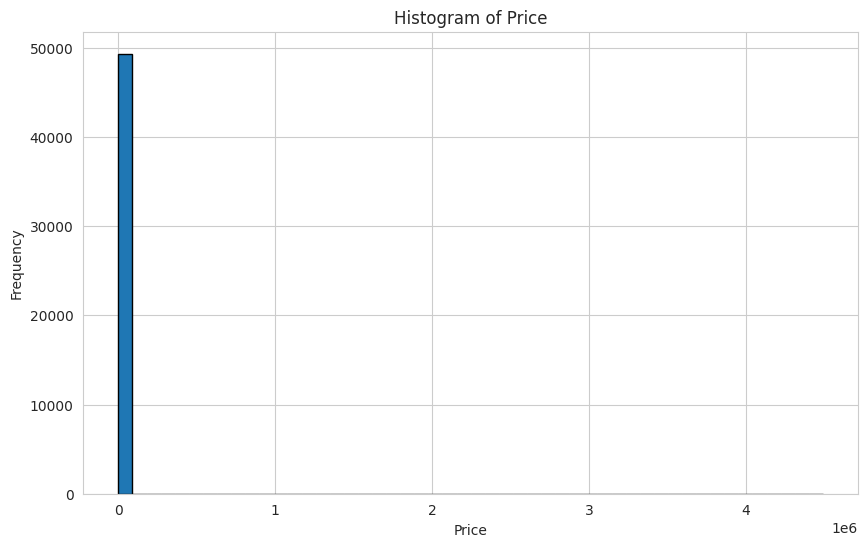

In [302]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df_new['price'].describe())

plt.figure(figsize=(10, 6))
plt.hist(df_new['price'], bins=50, edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of Price')
plt.show()

#### b. Boxplot. What can you say about the target? Are there any outliers?

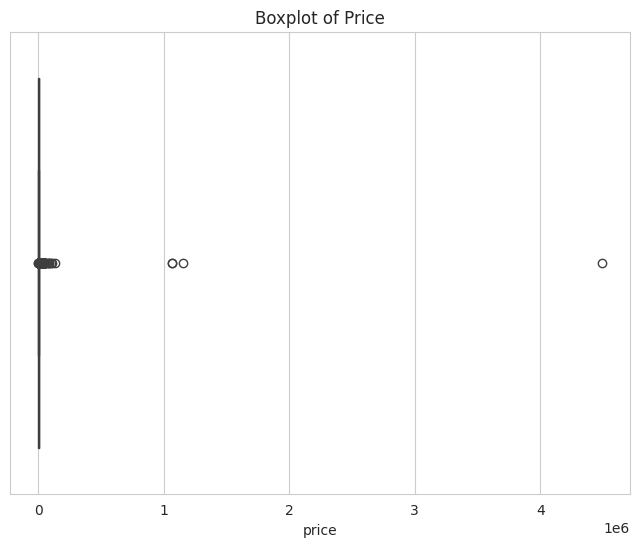

In [303]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_new['price'])
plt.title('Boxplot of Price')
plt.show()

**Вывод:** есть множество выбросов в верхней части распределения

#### c. Drop the rows that are outside the 1 and 99 percentiles from the target column.

In [304]:
# Вычисляем 1-й и 99-й процентили
lower = df_new['price'].quantile(0.01)
upper = df_new['price'].quantile(0.99)

print(f"1-й процентиль (нижняя граница): {lower:.2f}")
print(f"99-й процентиль (верхняя граница): {upper:.2f}")

df_clean = df_new[(df_new['price'] >= lower) & (df_new['price'] <= upper)]

print(f"\nБыло строк: {len(df_new)}")
print(f"Стало строк: {len(df_clean)}")
print(f"Удалено строк: {len(df_new) - len(df_clean)}")
print(f"Удалено %: {(len(df_new) - len(df_clean)) / len(df_new) * 100:.2f}%")

1-й процентиль (нижняя граница): 1475.00
99-й процентиль (верхняя граница): 13000.00

Было строк: 49352
Стало строк: 48379
Удалено строк: 973
Удалено %: 1.97%


#### d. Histogram after cleaning

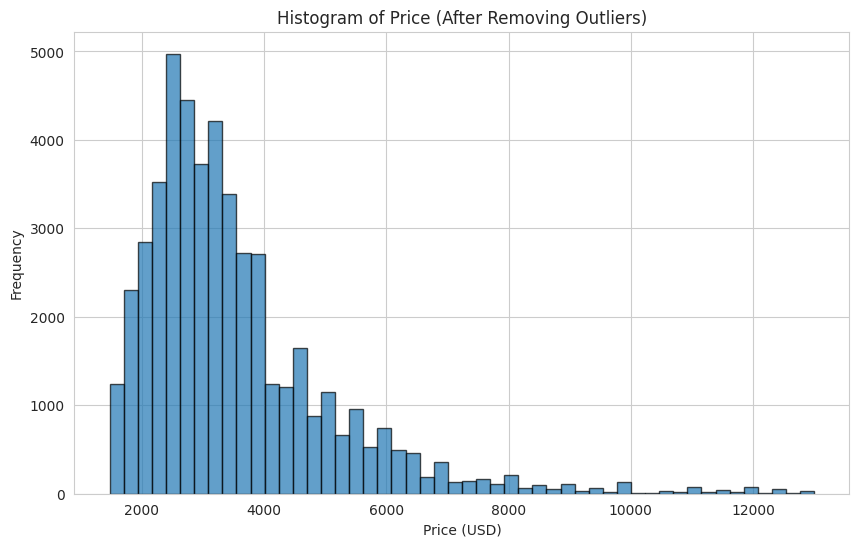

In [305]:
plt.figure(figsize=(10, 6))
plt.hist(df_clean['price'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.title('Histogram of Price (After Removing Outliers)')
plt.show()

### Гистограмма price после удаления выбросов

**Результаты:**
- Диапазон цен: от 1475 до 13000 (после отсечения 1 и 99 процентилей)
- Пик распределения приходится на интервал 2500-3500 с частотой около 4500-5000 объявлений
- Распределение имеет положительную асимметрию (правый хвост длиннее левого)
- После 6000 количество объявлений плавно уменьшается

**Вывод:** удаление выбросов сделало распределение более компактным и пригодным для обучения модели. Аномально дорогие квартиры (до 4.49 млн) исключены из анализа.

### IV. Characteristics Analysis

#### a. What is the type of column 'interest_level'?

In [306]:
print(f"Тип данных interest_level: {df_clean['interest_level'].dtype}")

Тип данных interest_level: str


#### b. How many entries does each value contain?

In [307]:
print("Значения в interest_level:")
print(df_clean['interest_level'].value_counts())

Значения в interest_level:
interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64


#### c. Encode these values. For example, you can replace each value with 0, 1, or 2.

In [308]:
mapping = {'high': 2, 'medium': 1, 'low': 0}
df_clean['interest_encoded'] = df_clean['interest_level'].map(mapping)

print("\nПосле кодирования:")
print(df_clean[['interest_level', 'interest_encoded']].head())


После кодирования:
   interest_level  interest_encoded
4          medium                 1
6             low                 0
9          medium                 1
10         medium                 1
15            low                 0


#### d. Plot histograms for the features 'bathrooms', 'bedrooms'. Are there any outliers?

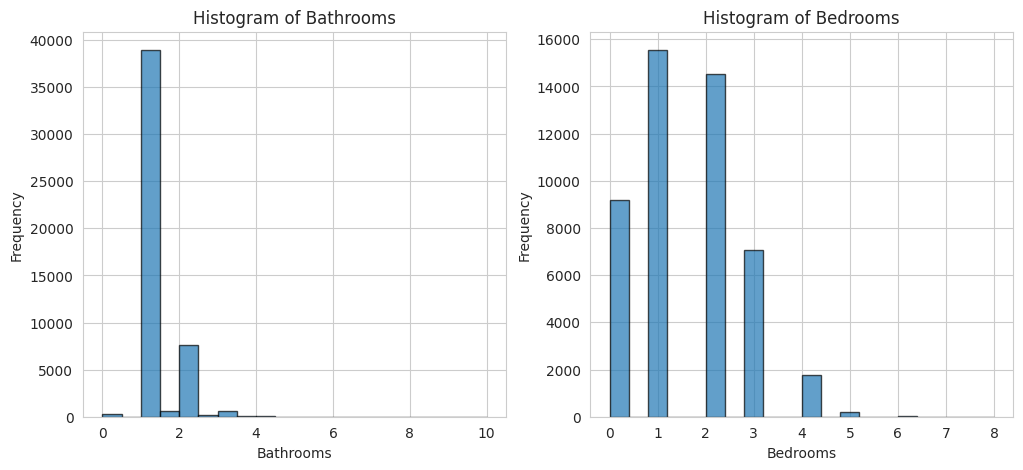

In [309]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_clean['bathrooms'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Bathrooms')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram of Bathrooms')

axes[1].hist(df_clean['bedrooms'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Bedrooms')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Histogram of Bedrooms')

plt.show()

In [310]:
print("Статистика bathrooms:")
print(df_clean['bathrooms'].describe())
print("-" * 100)
print("\nСтатистика bedrooms:")
print(df_clean['bedrooms'].describe())
print("-" * 100)
print(df_clean['interest_level'].value_counts())

Статистика bathrooms:
count    48379.000000
mean         1.195198
std          0.456495
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         10.000000
Name: bathrooms, dtype: float64
----------------------------------------------------------------------------------------------------

Статистика bedrooms:
count    48379.000000
mean         1.534633
std          1.101477
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: bedrooms, dtype: float64
----------------------------------------------------------------------------------------------------
interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64


**Вывод по выбросам в признаках**
В отличие от целевой переменной price, признаки *bathrooms* и *bedrooms* не содержат аномальных выбросов, требующих удаления. Экстремальные значения (например, 10 ванных комнат) соответствуют реальным объявлениям.

### V. Complex analysis

#### a. A Correlation matrix to understand the correlation between features and target

Корреляционная матрица:
                  bathrooms  bedrooms  interest_encoded     price
bathrooms          1.000000  0.517574         -0.063635  0.671943
bedrooms           0.517574  1.000000          0.050654  0.545948
interest_encoded  -0.063635  0.050654          1.000000 -0.200111
price              0.671943  0.545948         -0.200111  1.000000


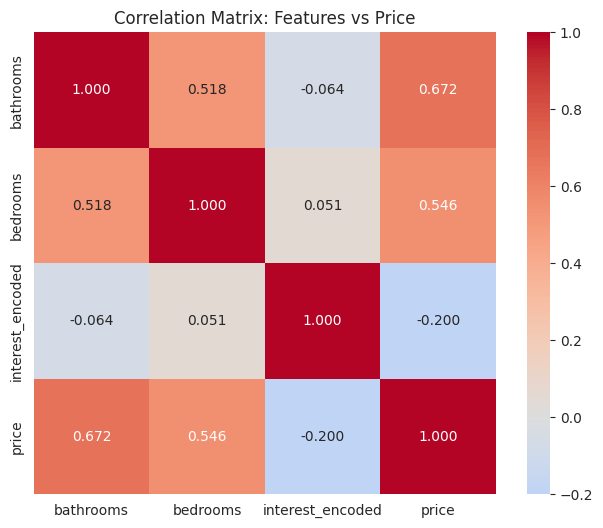

In [311]:
df_corr = df_clean.copy()
df_corr['interest_encoded'] = df_corr['interest_level'].map({'high': 2, 'medium': 1, 'low': 0})

numeric_cols = ['bathrooms', 'bedrooms', 'interest_encoded', 'price']
corr_matrix = df_corr[numeric_cols].corr()

print("Корреляционная матрица:")
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Correlation Matrix: Features vs Price')
plt.show()

#### b. A Scatterplot to visualize the correlation between the features and the target

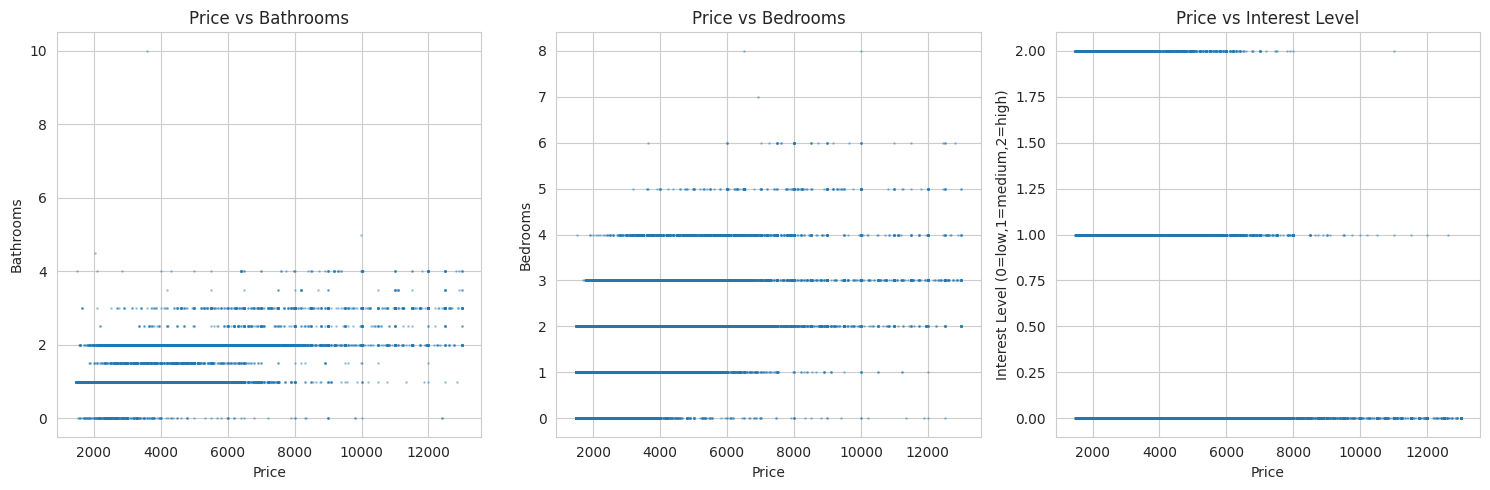

In [312]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Price vs Bathrooms
axes[0].scatter(df_corr['price'], df_corr['bathrooms'], alpha=0.3, s=1)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Bathrooms')
axes[0].set_title('Price vs Bathrooms')

# Price vs Bedrooms
axes[1].scatter(df_corr['price'], df_corr['bedrooms'], alpha=0.3, s=1)
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Bedrooms')
axes[1].set_title('Price vs Bedrooms')

# Price vs Interest Level
axes[2].scatter(df_corr['price'], df_corr['interest_encoded'], alpha=0.3, s=1)
axes[2].set_xlabel('Price')
axes[2].set_ylabel('Interest Level (0=low,1=medium,2=high)')
axes[2].set_title('Price vs Interest Level')

plt.tight_layout()
plt.show()

## 4. Creating Features

### I. Adding features

Новые признаки (первые 5 строк):
    bathrooms  bathrooms_squared  bedrooms  bedrooms_squared  \
4         1.0               1.00         1                 1   
6         1.0               1.00         2                 4   
9         1.0               1.00         2                 4   
10        1.5               2.25         3                 9   
15        1.0               1.00         0                 0   

    interest_encoded  interest_level_squared  
4                  1                       1  
6                  0                       0  
9                  1                       1  
10                 1                       1  
15                 0                       0  

Корреляция признаков с price:
price                     1.000000
bathrooms                 0.671943
bathrooms_squared         0.648486
bedrooms                  0.545948
bedrooms_squared          0.543406
interest_level_squared   -0.182672
interest_encoded         -0.200111
Name: price, dtype: floa

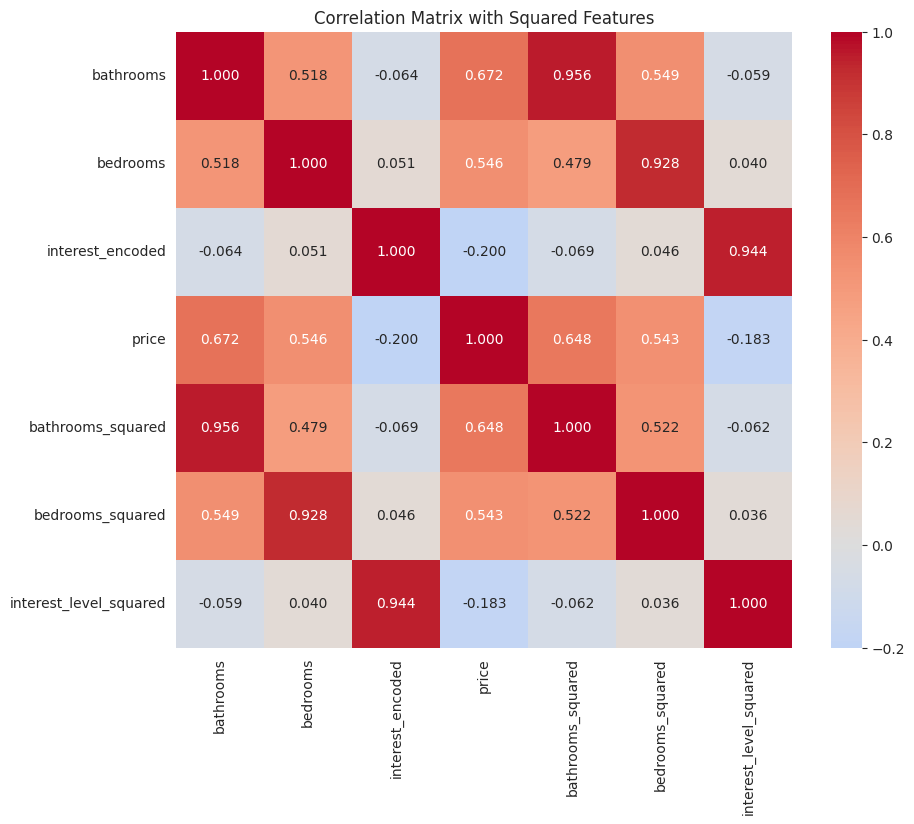

In [313]:
df_features = df_clean.copy()

mapping = {'high': 2, 'medium': 1, 'low': 0}
df_features['interest_encoded'] = df_features['interest_level'].map(mapping)

df_features['bathrooms_squared'] = df_features['bathrooms'] ** 2
df_features['bedrooms_squared'] = df_features['bedrooms'] ** 2
df_features['interest_level_squared'] = df_features['interest_encoded'] ** 2

print("Новые признаки (первые 5 строк):")
print(df_features[['bathrooms', 'bathrooms_squared', 
                   'bedrooms', 'bedrooms_squared',
                   'interest_encoded', 'interest_level_squared']].head())

numeric_cols = ['bathrooms', 'bedrooms', 'interest_encoded', 'price',
                'bathrooms_squared', 'bedrooms_squared', 'interest_level_squared']

corr_matrix = df_features[numeric_cols].corr()

print("\nКорреляция признаков с price:")
print(corr_matrix['price'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f', square=True)
plt.title('Correlation Matrix with Squared Features')
plt.show()

**Новые квадратичные признаки НЕ показали более высокой корреляции с целевой переменной, чем исходные.**

Значения корреляции практически идентичны:
- bathrooms (0.672) vs bathrooms_squared (0.648)
- bedrooms (0.546) vs bedrooms_squared (0.543)
- interest_encoded (-0.200) vs interest_level_squared (-0.183)

### V. Initialize PolynomialFeatures() with a degree of 10.

In [314]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

X = df_clean[['bathrooms', 'bedrooms']]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_test: {X_test.shape}")
print(f"Размер y_train: {y_train.shape}")
print(f"Размер y_test: {y_test.shape}")

poly = PolynomialFeatures(degree=10, include_bias=False)

X_train_poly = poly.fit_transform(X_train)

X_test_poly = poly.transform(X_test)

print(f"\nФорма X_train после: {X_train_poly.shape}")
print(f"Форма X_test после: {X_test_poly.shape}")
print(f"Количество признаков до: {X_train.shape[1]}")
print(f"Количество признаков после: {X_train_poly.shape[1]}")

Размер X_train: (38703, 2)
Размер X_test: (9676, 2)
Размер y_train: (38703,)
Размер y_test: (9676,)

Форма X_train после: (38703, 65)
Форма X_test после: (9676, 65)
Количество признаков до: 2
Количество признаков после: 65


## 5. Train 3 models: linear regression, decision tree and naive model

### I. Result table 

#### a. Two empty Pandas DataFrames

In [315]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

print("Таблицы созданы:")
print("result_MAE:", result_MAE.shape)
print("result_RMSE:", result_RMSE.shape)

Таблицы созданы:
result_MAE: (0, 3)
result_RMSE: (0, 3)


### II. Linear Regression

#### a. Initialize linear regression from sklearn with no parameters

In [316]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
print("Модель создана:", lr)

Модель создана: LinearRegression()


#### b. Fit your model and make predictions on training and test features. 

In [317]:
lr.fit(X_train_poly, y_train)
print("Модель обучена")

y_train_pred_lr = lr.predict(X_train_poly)
y_test_pred_lr = lr.predict(X_test_poly)

print(f"Предсказания на train: {len(y_train_pred_lr)} шт")
print(f"Предсказания на test: {len(y_test_pred_lr)} шт")
print(f"Первые 5 предсказаний на test: {y_test_pred_lr[:5]}")

Модель обучена
Предсказания на train: 38703 шт
Предсказания на test: 9676 шт
Первые 5 предсказаний на test: [3199.3040748  2477.65764278 3199.3040748  3036.23907285 2477.65764278]


#### c. Compute MAE on training and test targets

In [318]:
from sklearn.metrics import mean_absolute_error

mae_train = mean_absolute_error(y_train, y_train_pred_lr)
mae_test = mean_absolute_error(y_test, y_test_pred_lr)

print(f"MAE на train: {mae_train:.2f}")
print(f"MAE на test: {mae_test:.2f}")

MAE на train: 755.35
MAE на test: 760.74


#### d. Calculate RMSE on training and test objectives

In [319]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_lr))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print(f"RMSE на train: {rmse_train:.2f}")
print(f"RMSE на test: {rmse_test:.2f}")

RMSE на train: 1075.25
RMSE на test: 1100.03


#### e. Insert your metrics into tables result_MAE and result_RMSE with model name 'linear_regression'.

In [320]:
import pandas as pd

result_MAE = pd.concat([result_MAE, pd.DataFrame([{
    'model': 'linear_regression',
    'train': mae_train,
    'test': mae_test
}])], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{
    'model': 'linear_regression',
    'train': rmse_train,
    'test': rmse_test
}])], ignore_index=True)

print("Результаты добавлены в таблицы")
print("\nresult_MAE:")
print(result_MAE)
print("\nresult_RMSE:")
print(result_RMSE)

Результаты добавлены в таблицы

result_MAE:
               model       train        test
0  linear_regression  755.345491  760.735792

result_RMSE:
               model        train         test
0  linear_regression  1075.252157  1100.028649


### III. Decision Tree

#### a. Initialize decision tree regressor from sklearn with fixed random_state=21.

In [321]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=21)
print("Модель создана:", dt)

Модель создана: DecisionTreeRegressor(random_state=21)


#### b. Fit it to train features and train target and make prediction on train and test features.

In [322]:
dt.fit(X_train_poly, y_train)
print("Модель обучена")

y_train_pred_dt = dt.predict(X_train_poly)
y_test_pred_dt = dt.predict(X_test_poly)

print(f"Предсказания на train: {len(y_train_pred_dt)} шт")
print(f"Предсказания на test: {len(y_test_pred_dt)} шт")
print(f"Первые 5 предсказаний на test: {y_test_pred_dt[:5]}")

Модель обучена
Предсказания на train: 38703 шт
Предсказания на test: 9676 шт
Первые 5 предсказаний на test: [3199.50211598 2477.57604138 3199.50211598 3036.10009935 2477.57604138]


#### c. Compute MAE on train and test targets

In [323]:
from sklearn.metrics import mean_absolute_error

mae_train_dt = mean_absolute_error(y_train, y_train_pred_dt)
mae_test_dt = mean_absolute_error(y_test, y_test_pred_dt)

print(f"MAE на train: {mae_train_dt:.2f}")
print(f"MAE на test: {mae_test_dt:.2f}")

MAE на train: 755.35
MAE на test: 759.22


#### d. Compute RMSE on train and test targets

In [324]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse_train_dt = np.sqrt(mean_squared_error(y_train, y_train_pred_dt))
rmse_test_dt = np.sqrt(mean_squared_error(y_test, y_test_pred_dt))

print(f"RMSE на train: {rmse_train_dt:.2f}")
print(f"RMSE на test: {rmse_test_dt:.2f}")

RMSE на train: 1075.21
RMSE на test: 1088.43


#### e. Insert your metrics into tables result_MAE and result_RMSE with model name 'decision_tree'.

In [325]:
import pandas as pd

result_MAE = pd.concat([result_MAE, pd.DataFrame([{
    'model': 'decision_tree',
    'train': mae_train_dt,
    'test': mae_test_dt
}])], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{
    'model': 'decision_tree',
    'train': rmse_train_dt,
    'test': rmse_test_dt
}])], ignore_index=True)

print("Результаты добавлены в таблицы")
print("\nresult_MAE:")
print(result_MAE)
print("\nresult_RMSE:")
print(result_RMSE)

Результаты добавлены в таблицы

result_MAE:
               model       train        test
0  linear_regression  755.345491  760.735792
1      decision_tree  755.352697  759.222259

result_RMSE:
               model        train         test
0  linear_regression  1075.252157  1100.028649
1      decision_tree  1075.206434  1088.427831


In [326]:
print(f"Глубина дерева: {dt.get_depth()}")
print(f"Количество листьев: {dt.get_n_leaves()}")

Глубина дерева: 11
Количество листьев: 52


### IV. Naive Models

#### a. Calculate the mean and median of 'price' on the training and test data and create a column with these values

In [327]:
mean_train = y_train.mean()
median_train = y_train.median()

print(f"Среднее (mean) на train: {mean_train:.2f}")
print(f"Медиана (median) на train: {median_train:.2f}")

y_train_pred_mean = np.full_like(y_train, mean_train)
y_test_pred_mean = np.full_like(y_test, mean_train)
y_train_pred_median = np.full_like(y_train, median_train)
y_test_pred_median = np.full_like(y_test, median_train)

print("Naive Mean - первые 5 предсказаний на test:")
print(y_test_pred_mean[:5])
print("\nNaive Median - первые 5 предсказаний на test:")
print(y_test_pred_median[:5])

Среднее (mean) на train: 3537.26
Медиана (median) на train: 3150.00
Naive Mean - первые 5 предсказаний на test:
[3537 3537 3537 3537 3537]

Naive Median - первые 5 предсказаний на test:
[3150 3150 3150 3150 3150]


#### b. Calculate the MAE on the training and test targets between your target and the calculated mean and median.

In [328]:
mae_train_mean = mean_absolute_error(y_train, y_train_pred_mean)
mae_test_mean = mean_absolute_error(y_test, y_test_pred_mean)

mae_train_median = mean_absolute_error(y_train, y_train_pred_median)
mae_test_median = mean_absolute_error(y_test, y_test_pred_median)

print("MAE RESULTS")
print()
print(f"Naive Mean  - MAE train: {mae_train_mean:.2f}, test: {mae_test_mean:.2f}")
print(f"Naive Median - MAE train: {mae_train_median:.2f}, test: {mae_test_median:.2f}")

MAE RESULTS

Naive Mean  - MAE train: 1137.69, test: 1143.01
Naive Median - MAE train: 1084.59, test: 1092.70


#### c. Calculate the RMSE on the training and test targets between your target and the calculated mean and median.

In [329]:
rmse_train_mean = np.sqrt(mean_squared_error(y_train, y_train_pred_mean))
rmse_test_mean = np.sqrt(mean_squared_error(y_test, y_test_pred_mean))

rmse_train_median = np.sqrt(mean_squared_error(y_train, y_train_pred_median))
rmse_test_median = np.sqrt(mean_squared_error(y_test, y_test_pred_median))

print("RMSE RESULTS")
print()
print(f"Naive Mean  - RMSE train: {rmse_train_mean:.2f}, test: {rmse_test_mean:.2f}")
print(f"Naive Median - RMSE train: {rmse_train_median:.2f}, test: {rmse_test_median:.2f}")

RMSE RESULTS

Naive Mean  - RMSE train: 1599.23, test: 1591.30
Naive Median - RMSE train: 1645.45, test: 1639.38


#### Insert metrics into tables 

In [330]:
result_MAE = pd.concat([result_MAE, pd.DataFrame([{
    'model': 'naive_mean',
    'train': mae_train_mean,
    'test': mae_test_mean
}])], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{
    'model': 'naive_mean',
    'train': rmse_train_mean,
    'test': rmse_test_mean
}])], ignore_index=True)

result_MAE = pd.concat([result_MAE, pd.DataFrame([{
    'model': 'naive_median',
    'train': mae_train_median,
    'test': mae_test_median
}])], ignore_index=True)

result_RMSE = pd.concat([result_RMSE, pd.DataFrame([{
    'model': 'naive_median',
    'train': rmse_train_median,
    'test': rmse_test_median
}])], ignore_index=True)

print("Результаты добавлены в таблицы")

Результаты добавлены в таблицы


### V. Compare the results

#### a. Print your final result_MAE and result_RMSE tables.

In [ ]:
print("\nresult_MAE:")
print(result_MAE)
print("\nresult_RMSE:")
print(result_RMSE)


result_MAE:


NameError: name 'result_MAE' is not defined

#### b. Which is the best model?

**Decision Tree** показывает наилучшие результаты:
- Наименьшая MAE на тестовых данных (759.22)
- Наименьшая RMSE на тестовых данных (1088.43)

Обе обученные модели (Linear Regression и Decision Tree) значительно превосходят наивные модели (mean/median), что подтверждает, что признаки bathrooms и bedrooms действительно влияют на цену аренды.

Переобучения (overfitting) не наблюдается, так как метрики на train и test близки.